# MNIST Autoencoder
### Directives
* Create the autoencoders described below, you can play with the topology, those are just starting points
* Use GPU runtime
* Print 10 inputs and their associated outputs
* Don't forget to normalize your data
* Use the Functional API for Keras

### Autoencoders to build
1. Stacked 784 - 392 - 196 - 392 - 784 (tied weights)
2. Convolutional Encoder (conv, maxpool, conv, maxpool, conv, maxpool). Decoder (conv, upsample2d, conv, upsample2d, conv, upsample2d, conv)


In [ ]:
# Choose Python 3 runtime
!pip install --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 45.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently

In [2]:
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(X_train, _), (X_test, _) = mnist.load_data()
all_data = np.concatenate((X_train, X_test))
all_data.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


(70000, 28, 28)

In [3]:
def print_first_9(data):
  fig = plt.figure()
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(data[i], interpolation='none')
    plt.title("Digit: {}".format(i))
    plt.xticks([])
    plt.yticks([])

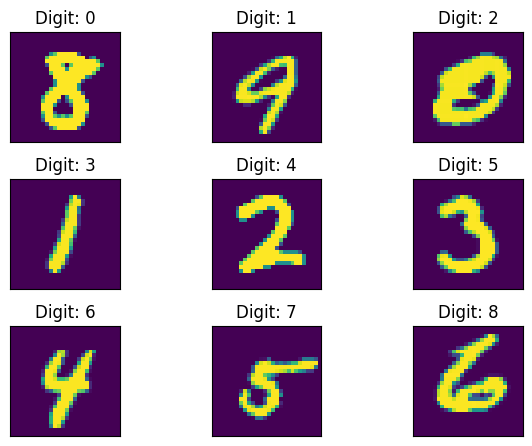

In [4]:
print_first_9(all_data[-9:])

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [7]:
print("Number of GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Number of GPUs Available: 1


In [9]:
X_train = X_train.astype("float32") / 255.
X_test = X_test.astype("float32") / 255.

X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)

# Stacked Autoencoder (Tied Weights)

In [10]:
input_img = keras.Input(shape=(784,))

encoded1 = layers.Dense(392, activation='relu')
encoded2 = layers.Dense(196, activation='relu')

h1 = encoded1(input_img)
h2 = encoded2(h1)

decoded1 = layers.Dense(
    392,
    activation='relu',
    use_bias=True,
    kernel_initializer=tf.keras.initializers.Identity()
)(h2)

decoded2 = layers.Dense(
    784,
    activation='sigmoid'
)(decoded1)

autoencoder_dense = keras.Model(input_img, decoded2)

autoencoder_dense.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder_dense.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 392)            │        77,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       308,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,084 (2.94 MB)

 Trainable params: 770,084 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
autoencoder_dense.fit(
    X_train_flat,
    X_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0699 - val_loss: 0.0041
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - loss: 0.0041 - val_loss: 0.0041
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 0.0040 - val_loss: 0.0041
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 0.0040 - val_loss: 0.0040
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - loss: 0.0039 - val_loss: 0.0040
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 869us/step - loss: 0.0039 - val_loss: 0.0040


# Convolutional Autoencoder

In [12]:
input_img = keras.Input(shape=(28,28,1))

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(8, (3,3), activation='relu', padding='same')(x)

encoded = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder_cnn = keras.Model(input_img, decoded)

autoencoder_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder_cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder_cnn.fit(
    X_train_cnn,
    X_train_cnn,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_cnn, X_test_cnn)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0296 - val_loss: 0.0040
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0038 - val_loss: 0.0038


# 10 Inputs and Outputs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step


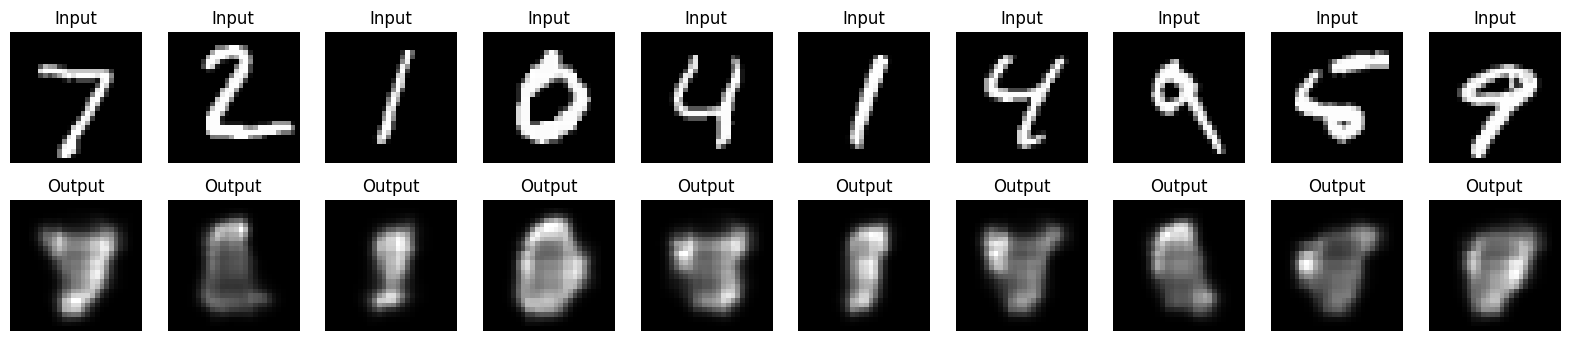

In [16]:
decoded_imgs = autoencoder_cnn.predict(X_test_cnn[:10])

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(X_test_cnn[i].reshape(28,28), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Output")
    plt.axis("off")

plt.show()